In [1]:
import sys;from pathlib import Path;sys.path.insert(0, str(Path().resolve()))

import torch
import matplotlib.pyplot as plt
import random
from PIL import Image
from IPython.display import display, clear_output

from transformers import CLIPTokenizer
from module import model_loader, pipeline

from trainer.dataset import ImageTextDataset
from trainer.train_vae import VAETrainer
from trainer.train_diffusion import DiffusionTrainer

torch.set_float32_matmul_precision('high')
DEVICE = "cuda" if torch.cuda.is_available() else 'cpu'
DTYPE = torch.bfloat16 if DEVICE=="cuda" else torch.bfloat32
DEVICE, DTYPE

('cuda', torch.bfloat16)

## VAE Trainning

### Train

🔄 Initializing VAE_Encoder and VAE_Decoder...
✅ Initialization finished!
🔄 Initializing encoder...
🔄 Loading model/base-v1-5-pruned-emaonly.safetensors for encoder...
✅ Finished!
🔄 Initializing decoder...
🔄 Loading model/base-v1-5-pruned-emaonly.safetensors for decoder...
✅ Finished!
📂 Loading dataset...
📂 Loaded 1000 image-text pairs from dataset/minecraft-preview/


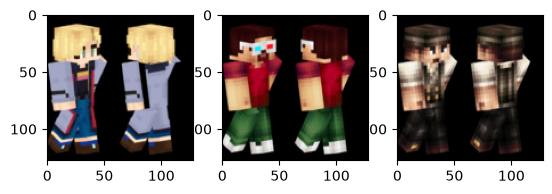

Caption 1: The 13th Doctor from the British television series Doctor Who.
Caption 2: A male wearing 3D glasses.
Caption 3: Gangster from the 1950s.
🔄 Initializing Loss, optimizer and scheduler...
Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]
Loading model from: E:\Projects\Jypyter Notebook Projects\.venv\Lib\site-packages\lpips\weights\v0.1\vgg.pth
✅ Initialization finished!

📊 Configuration:
   DATASET DIRECTORY:    dataset/minecraft-preview/
   DATASET SIZE:         1000
   CHECKPOINT DIRECTORY: checkpoint/vae
   PRETRAIN MODEL PATH:  model/base-v1-5-pruned-emaonly.safetensors
   IMAGE SIZE:           128x128
   BATCH SIZE:           16
   NUM WORKERS:          8
   LEARNING RATE:        0.0001
   TOTAL EPOCHS:         2
   LPIPS WEIGHT:         0.1
   KL WEIGHT:            1e-06
   SAVE INTERVAL:        2
   DEVICE:               cuda
✅ **All initialization is ready, start training using trainer.train()**
📂 Checkpoint loaded: checkpoint/vae/vae_epoch_45.pt (

In [6]:
trainer = VAETrainer('dataset/minecraft-preview/', 
                     output_dir="checkpoint/vae",
                     from_pretrain = "model/base-v1-5-pruned-emaonly.safetensors",
                     image_size = 128,
                     batch_size = 16,
                     num_workers = 8,
                     learning_rate = 1e-4,
                     num_epochs = 2,
                     lpips_weight = 0.1,
                     kl_weight = 1e-6,
                     save_every = 2,
                     device=DEVICE)
trainer.load_checkpoint("checkpoint/vae/vae_epoch_45.pt")

🚀 Starting VAE training for 2 epochs...


Epoch 46/47: 100%|██████████| 62/62 [01:08<00:00,  1.11s/it, total=0.0284, recon=0.0221, kl=4269.1450]



📊 Epoch 46 Summary:
   Total: 0.027812
   Recon: 0.021434
   LPIPS: 0.021141
   KL:    4263.927979
   LR:    4.88e-05


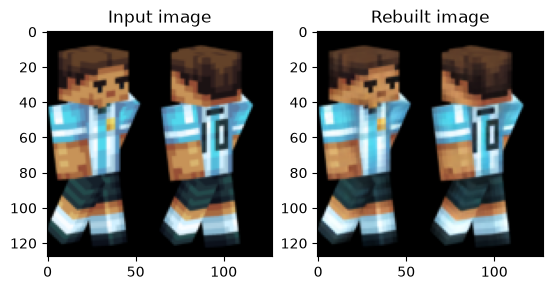

Epoch 47/47: 100%|██████████| 62/62 [01:08<00:00,  1.10s/it, total=0.0267, recon=0.0204, kl=4361.1895]



📊 Epoch 47 Summary:
   Total: 0.027285
   Recon: 0.020972
   LPIPS: 0.020533
   KL:    4259.925104
   LR:    4.70e-05


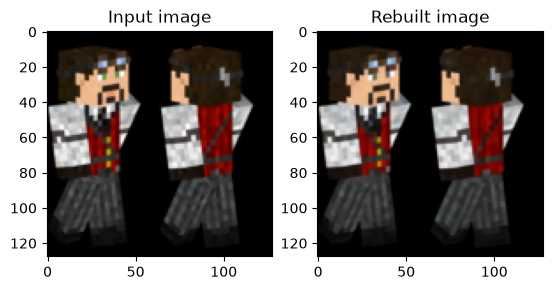

💾 Checkpoint saved: checkpoint/vae\vae_epoch_47.pt
✅ VAE training complete!


In [7]:
trainer.train()

### Eval

In [3]:
# Initialize dataset and vae models
dataset = ImageTextDataset("dataset/minecraft-preview/", image_size=128)
encoder = model_loader.get_model(name='encoder', ckp_path="checkpoint/vae/vae_epoch_45.pt", device=DEVICE, dtype=DTYPE).eval()
decoder = model_loader.get_model(name='decoder', ckp_path="checkpoint/vae/vae_epoch_45.pt", device=DEVICE, dtype=DTYPE).eval()

📂 Loaded 1000 image-text pairs from dataset/minecraft-preview/
🔄 Initializing encoder...
🔄 Loading checkpoint/vae/vae_epoch_45.pt for encoder...
✅ Finished!
🔄 Initializing decoder...
🔄 Loading checkpoint/vae/vae_epoch_45.pt for decoder...
✅ Finished!


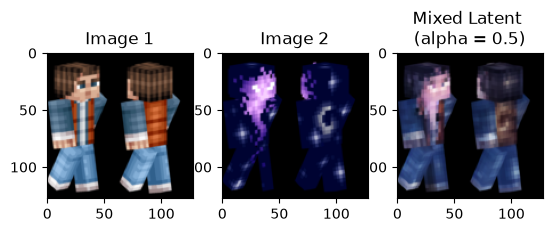

In [4]:
# Randomly select two images
idx1 = random.randint(0, len(dataset))
idx2 = random.randint(0, len(dataset))
img1 = dataset[idx1]['image'].unsqueeze(0).to(device=DEVICE, dtype=DTYPE)
img2 = dataset[idx2]['image'].unsqueeze(0).to(device=DEVICE, dtype=DTYPE)
noise = torch.randn(1, 4, 128 // 8, 128 // 8, device=DEVICE, dtype=DTYPE)

# Mix the latent space of the two using alpha as the ratio
alpha = 0.5
latent1 = encoder(img1, noise)
latent2 = encoder(img2, noise)
latent = (1 - alpha) * latent1 + alpha * latent2
rebuilt_img = decoder(latent)

# Display
post_process = lambda img: ((img.detach().squeeze(0).cpu().permute(1, 2, 0).clamp(-1, 1) + 1) / 2 * 255).byte()
fig, axs = plt.subplots(1, 3)
axs[0].imshow(post_process(img1))
axs[1].imshow(post_process(img2))
axs[2].imshow(post_process(rebuilt_img))
axs[0].set_title('Image 1')
axs[1].set_title('Image 2')
axs[2].set_title(f"Mixed Latent \n(alpha = {alpha})")
plt.show()

## Diffusion Training

### Train

🔄 Initializing CLIPTokenizer...
✅ Finished!
🔄 Initializing encoder...
🔄 Loading checkpoint/vae/vae_epoch_45.pt for encoder...
✅ Finished!
🔄 Initializing decoder...
🔄 Loading checkpoint/vae/vae_epoch_45.pt for decoder...
✅ Finished!
🔄 Initializing clip...
🔄 Loading model/base-v1-5-pruned-emaonly.safetensors for clip...
✅ Finished!
🔄 Initializing diffusion...
⏭️ Skip loading weights for diffusion...
✅ Finished!
🔄 Frozen encoder, decoder and clip...
✅ Finished!
📂 Loading dataset...
📂 Loaded 1000 image-text pairs from dataset/minecraft-preview/


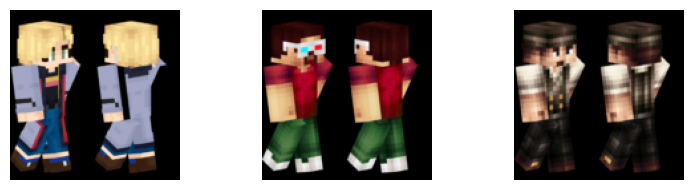

Caption 1: The 13th Doctor from the British television series Doctor Who.
Tokenized 1: tensor([49406,   518,   272,   274,   640,  5547,   633,   518,  3504,  8608,
         1857,  5547,   822,   269, 49407, 49407, 49407, 49407, 49407, 49407,
        49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407,
        49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407,
        49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407,
        49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407,
        49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407,
        49407, 49407, 49407, 49407, 49407, 49407, 49407])
Caption 2: A male wearing 3D glasses.
Tokenized 2: tensor([49406,   320,  2801,  3309,   274,   323,  6116,   269, 49407, 49407,
        49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407,
        49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407,
        49407, 49407, 49

In [2]:
diffusion_trainer = DiffusionTrainer(
    data_dir='dataset/minecraft-preview/',
    output_dir='checkpoint/diffusion',
    vae_ckp='checkpoint/vae/vae_epoch_45.pt',
    clip_ckp='model/base-v1-5-pruned-emaonly.safetensors',
    diffusion_ckp='',
    tokenizer_dir='tokenizer',
    image_size=128,
    batch_size=8,
    num_workers=8,
    learning_rate=1e-5,
    num_epochs=1,
    save_every=1,
    device=DEVICE
)
diffusion_trainer.load_checkpoint('checkpoint/diffusion/diffusion_epoch_4.pt')

🚀 Starting DiffusionModel training for 1 epochs...


Epoch 5/5: 100%|██████████| 125/125 [14:49<00:00,  7.11s/it, loss=0.0095]



📊 Epoch 5 summary：
   Average Loss: 0.046268
   LR:           3.16e-06


Sampling: 100%|██████████| 54/54 [00:18<00:00,  2.85step/s]


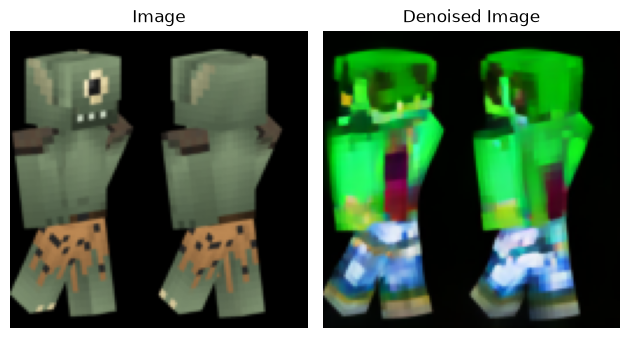

💾 Checkpoint saved: checkpoint/diffusion\diffusion_epoch_5.pt
✅ Training finished!


In [3]:
diffusion_trainer.train()

### Eval

In [2]:
tokenizer = CLIPTokenizer("tokenizer/vocab.json", "tokenizer/merges.txt")
models = {
    "encoder": model_loader.get_model(name='encoder', ckp_path="checkpoint/vae/vae_epoch_45.pt", device=DEVICE, dtype=DTYPE).eval(),
    "decoder": model_loader.get_model(name='decoder', ckp_path="checkpoint/vae/vae_epoch_45.pt", device=DEVICE, dtype=DTYPE).eval(),
    "clip": model_loader.get_model(name='clip', ckp_path="model/base-v1-5-pruned-emaonly.safetensors", device=DEVICE, dtype=DTYPE).eval(),
    "diffusion": model_loader.get_model(name='diffusion', ckp_path="checkpoint/diffusion/diffusion_epoch_4.pt", device=DEVICE, dtype=DTYPE).eval(),
}

🔄 Initializing encoder...
🔄 Loading checkpoint/vae/vae_epoch_45.pt for encoder...
✅ Finished!
🔄 Initializing decoder...
🔄 Loading checkpoint/vae/vae_epoch_45.pt for decoder...
✅ Finished!
🔄 Initializing clip...
🔄 Loading model/base-v1-5-pruned-emaonly.safetensors for clip...
✅ Finished!
🔄 Initializing diffusion...
🔄 Loading checkpoint/diffusion/diffusion_epoch_4.pt for diffusion...
✅ Finished!


In [3]:
prompt = "A male wearing 3D glasses."
uncond_prompt = ""

In [4]:
##### Generated size
img_width = 128
img_height = 128

##### Generation parameters
do_cfg = False
cfg_scale = 7.0
num_inference_steps = 32
num_training_steps = 1000
seed = random.randint(0, int(1e8))
decode_interval = 10

##### Image to image
input_image = None
strength = 1.0

##### Sampler
#sampler_name = "ddpm"
sampler_name = "ddpm"
ddim_eta = 0.2

##### GENERATION LOOP
generator = pipeline.generate(
    prompt=prompt,
    uncond_prompt=uncond_prompt,
    img_width=img_width,
    img_height=img_height,
    input_image=input_image,
    strength=strength,
    do_cfg=do_cfg,
    cfg_scale=cfg_scale,
    sampler_name=sampler_name,
    n_inference_steps=num_inference_steps,
    num_training_steps=num_training_steps,
    models=models,
    seed=seed,
    device=DEVICE,
    dtype=DTYPE,
    tokenizer=tokenizer,
    ddim_eta=ddim_eta,
    decode_interval=decode_interval
)

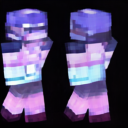

Sampling: 100%|██████████| 33/33 [00:04<00:00,  7.50step/s]


In [5]:
for output_image in generator:
    pil_img = Image.fromarray(output_image[0])
    clear_output(wait=True)
    display(pil_img)